In [8]:
import numpy as np
import pandas as pd
import os
import sys
import glob
from sklearn.metrics import classification_report, recall_score
import tqdm
import re
import ast
from typing import List
import matplotlib.pyplot as plt
os.chdir("/data/resources/weichel-llama3/work/projects/nace_classification/nace_report_topic_analysis")
sys.path.append("../../benchmark")
import test_base
from sentence_splitter import split_text_into_sentences
#from BERT_classifier.Classify_report_with_BERT import classification_report_BERT
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from preprocessing import preprocess_report

In [9]:
sentence_length = 6

## Test using a BERT-Classification Model trained on paragraphs to classify an entire report.

**Function:** pdf -> NACE Class

In [10]:
dataset_path = "data/datasets/german_annual_reports"
dataset_path = "data/datasets/stoxx_600_extended"
dataset_path = "data/datasets/reports_subset_from_full_data_1"
dataset_path = "data/datasets/reports_subset_from_full_data_3"
dataset_path = "data/datasets/stoxx_600"

In [11]:
over_view_df_path = os.path.join(dataset_path, os.path.basename(dataset_path) + "_overview.csv")

dataset_path_texts = os.path.join(dataset_path, "TXTs")

dataset_name = os.path.basename(dataset_path)

In [12]:
results_path = "results/BERT_classification/dataset__stoxx_600_sentence_len_6__nace_level_1"
results_path = "results/BERT_classification/2_dataset__reports_subset_from_full_data_1_sentence_len_6__nace_level_1"
results_path = "results/BERT_classification/model_2_1__sdataset__reports_subset_from_full_data_3_sentence_len_6__nace_level_1"
results_path = "results/BERT_classification/model_1_0__sdataset__reports_subset_from_full_data_3_sentence_len_6__nace_level_1"
results_path = "results/BERT_classification/model_0_1__dataset__stoxx_600_sentence_len_6__nace_level_1"
results_path = "results/BERT_classification/test_1_dataset__stoxx_600_sentence_len_6__nace_level_1"
reports_results = glob.glob(results_path+ "/*/*.csv")
len(reports_results)

226

In [13]:
nace_classes = pd.read_csv(over_view_df_path, index_col=0, sep=",")
nace_classes.head()

,Name,Symbol,FactSet ID,Revenue - 2022 (in EUR),Revenue - 2023 (in EUR),Revenue - 2024 (in EUR),NACE,NACE_letter,Report
0,SalMar ASA,SALM-NO,SALM-NO,1984.965581,2458.824022,2271.61166349053,3.21,A,salmar-annual-report-2022.pdf
1,Bakkafrost P/F,BAKKA-NO,BAKKA-NO,929.503079,937.862170,973.053513491168,3.21,A,Bakkafrost PF2.pdf
2,Antofagasta plc,ANTO-GB,ANTO-GB,5577.681426,5849.975673,6113.94698310345,7.29,B,Antofagasta plc1.pdf
3,Anglo American plc,AAL-GB,AAL-GB,33423.271144,28355.894415,25288.1884924262,7.29,B,Anglo American plc1.pdf
4,TotalEnergies SE,TTE-FR,TTE-FR,250538.948328,202517.658053,180837.266896225,6.10,B,Totalenergies EP Gabon1.pdf


In [14]:
report_to_nace_class = nace_classes.dropna(subset=["Report"]).set_index('Report').to_dict()["NACE"]
report_to_nace_class = {report[0][:-4] + ".txt": report[1] for report in report_to_nace_class.items()}
len(report_to_nace_class)

294

In [15]:
reports_path = glob.glob(os.path.join(dataset_path_texts, "*.txt"))
len(reports_path)

263

In [17]:
# ckpt = "results/BERT_models/results_null_classifiers__cos_thres_0.5__bert-base-uncased__train_full_model__some_labels/checkpoint-2331"
# ckpt = "results/BERT_models/results__new_approach_data__num_layers_2bert-base-uncased__train_full_model__some_labels/checkpoint-15990"
# model = classification_report_BERT.load_custom_bert_from_checkpoint(ckpt_path=ckpt)
# tokenizer = AutoTokenizer.from_pretrained(ckpt)

In [18]:
import numpy as np
import pandas as pd

# assume df is your dataframe
def softmax(x):
    e = np.exp(x - np.max(x))   # subtract max for numerical stability
    return e / e.sum()

In [19]:
def majority_vote(df: pd.DataFrame, scores: list, threshold: float = 0) -> dict:
    
    df["max_class_sim"] = [scores[i] for i in np.argmax(df[scores], 1)]
    df["max_sim"] = df[scores].max(1)
    df = df[df["max_sim"] > threshold]
    evaluation = (df["max_class_sim"].value_counts() / len(df)).sort_values(ascending=False).to_dict()

    return evaluation

In [20]:
def confidence_weighted_voting(df: pd.DataFrame, scores: list, threshold: float = 0) -> dict:

    df["max_class_sim"] = [scores[i] for i in np.argmax(df[scores], 1)]
    df["max_sim"] = df[scores].max(1)
    df = df[df["max_sim"] > threshold]
    evaluation = (df.groupby("max_class_sim")["max_sim"].sum().sort_values(ascending=False)/len(df)).to_dict()

    return evaluation

In [21]:
def logit_stacking(df: pd.DataFrame, scores: list, threshold: float = 0) -> dict:

    df["max_sim"] = df[scores].max(1)
    df = df[df["max_sim"] > threshold]

    stacked = df[scores].sum(0)
    
    evaluation = stacked.to_dict()

    return evaluation

In [22]:
#reports_results = ['../../results/BERT_classification/test_1/Heritage Foods Limited1.txt/Heritage Foods Limited1.txt_classifications.csv']

In [23]:
def mean_reciprocal_rank(position_levels):
    """
    Compute Mean Reciprocal Rank (MRR)
    position_levels: list or array of integer ranks (0 = correct, 1 = 2nd, ...)
    """
    ranks = np.array(position_levels) + 1  # convert 0-based to 1-based ranks
    reciprocal_ranks = 1 / ranks
    return np.mean(reciprocal_ranks)

def recall_score(y_true, y_pred):
    y_true_bin = (np.array(y_true) == 0).astype(int)
    y_pred_bin = (np.array(y_pred) == 0).astype(int)
    tp = np.sum((y_true_bin == 1) & (y_pred_bin == 1))
    fn = np.sum((y_true_bin == 1) & (y_pred_bin == 0))
    return tp / (tp + fn) if (tp + fn) > 0 else 0.0


def precision_score(y_true, y_pred):
    y_true_bin = (np.array(y_true) == 0).astype(int)
    y_pred_bin = (np.array(y_pred) == 0).astype(int)
    tp = np.sum((y_true_bin == 1) & (y_pred_bin == 1))
    fp = np.sum((y_true_bin == 0) & (y_pred_bin == 1))
    return tp / (tp + fp) if (tp + fp) > 0 else 0.0


def accuracy_score(y_true, y_pred):
    y_true_bin = (np.array(y_true) == 0).astype(int)
    y_pred_bin = (np.array(y_pred) == 0).astype(int)
    return np.mean(y_true_bin == y_pred_bin)


def f1_score(y_true, y_pred):
    p = precision_score(y_true, y_pred)
    r = recall_score(y_true, y_pred)
    return (2 * p * r) / (p + r) if (p + r) > 0 else 0.0


def mean_reciprocal_rank(position_levels):
    ranks = np.array(position_levels) + 1  # convert 0-based to 1-based ranks
    reciprocal_ranks = 1 / ranks
    return np.mean(reciprocal_ranks)

In [24]:
confidence_weighted_voting.__name__

'confidence_weighted_voting'

In [25]:
reports_results

['results/BERT_classification/test_1_dataset__stoxx_600_sentence_len_6__nace_level_1/Hannover Rueck SE1.txt/Hannover Rueck SE1.txt_classifications.csv',
 'results/BERT_classification/test_1_dataset__stoxx_600_sentence_len_6__nace_level_1/Interpump Group S.p.A.1.txt/Interpump Group S.p.A.1.txt_classifications.csv',
 'results/BERT_classification/test_1_dataset__stoxx_600_sentence_len_6__nace_level_1/Intertek Group PLC1.txt/Intertek Group PLC1.txt_classifications.csv',
 'results/BERT_classification/test_1_dataset__stoxx_600_sentence_len_6__nace_level_1/Anheuser-Busch InBev SANV3.txt/Anheuser-Busch InBev SANV3.txt_classifications.csv',
 'results/BERT_classification/test_1_dataset__stoxx_600_sentence_len_6__nace_level_1/Scout24 SE3.txt/Scout24 SE3.txt_classifications.csv',
 'results/BERT_classification/test_1_dataset__stoxx_600_sentence_len_6__nace_level_1/Bridgepoint Group Plc1.txt/Bridgepoint Group Plc1.txt_classifications.csv',
 'results/BERT_classification/test_1_dataset__stoxx_600_sent

In [27]:
reports_results[:]

['results/BERT_classification/test_1_dataset__stoxx_600_sentence_len_6__nace_level_1/Hannover Rueck SE1.txt/Hannover Rueck SE1.txt_classifications.csv',
 'results/BERT_classification/test_1_dataset__stoxx_600_sentence_len_6__nace_level_1/Interpump Group S.p.A.1.txt/Interpump Group S.p.A.1.txt_classifications.csv',
 'results/BERT_classification/test_1_dataset__stoxx_600_sentence_len_6__nace_level_1/Intertek Group PLC1.txt/Intertek Group PLC1.txt_classifications.csv',
 'results/BERT_classification/test_1_dataset__stoxx_600_sentence_len_6__nace_level_1/Anheuser-Busch InBev SANV3.txt/Anheuser-Busch InBev SANV3.txt_classifications.csv',
 'results/BERT_classification/test_1_dataset__stoxx_600_sentence_len_6__nace_level_1/Scout24 SE3.txt/Scout24 SE3.txt_classifications.csv',
 'results/BERT_classification/test_1_dataset__stoxx_600_sentence_len_6__nace_level_1/Bridgepoint Group Plc1.txt/Bridgepoint Group Plc1.txt_classifications.csv',
 'results/BERT_classification/test_1_dataset__stoxx_600_sent

In [28]:
df_eval

,F,C,NO_CLASS,M,L,H,P,G,D,J,Q,I,N,E,K,A,B,Sentences
0,-1.885066,-2.819561,5.129727,4.424354,-2.883533,-3.592367,-0.942608,-1.598908,-1.596512,-0.250578,-0.669838,-0.976792,1.124773,-2.462998,0.915302,-2.693325,-2.767827,fast forward with generation works tfmc uk par...
1,-1.619906,-3.383998,5.169343,-1.477012,-0.751935,-1.066768,-1.940865,1.129215,-1.547971,-3.167835,-0.436962,0.144394,1.332436,-1.925448,3.339035,-2.324942,-2.631403,working seamlessly across the corporate and cr...
2,-1.595970,-1.312776,3.467154,-3.410571,-1.838153,-0.191265,-2.127081,6.089218,-1.648839,-5.142942,-1.049311,-1.407891,1.592251,-1.226509,1.986910,-2.379771,-2.710973,in accordance with european regulation of june...
3,-2.148331,-3.941722,4.884419,-0.897385,-2.247921,-0.792199,-0.066348,1.830877,-1.595852,-2.657148,4.822220,-0.173698,0.703601,-4.495485,0.386945,-4.177216,-4.222327,while adsupported revenue was pressured in the...
4,-1.363685,-2.652423,5.539192,1.491852,-2.431528,-2.549232,-0.154549,-0.120616,-0.454823,-0.501381,1.072811,-0.839092,-0.347808,-3.324262,-0.145176,-2.869961,-3.155870,immersive audio umg is carrying out a multiyea...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1631,-1.797224,-3.142301,3.863062,-2.626064,0.080223,-0.538623,-1.032898,4.165091,-1.302549,-4.094617,2.587158,-0.294442,-0.308686,-2.767786,2.017684,-2.607806,-3.061909,physical our physical recorded music products ...
1632,-1.478906,-3.002460,3.058758,5.749309,-2.131195,-3.175551,-0.787041,-2.355187,-3.021217,0.472763,-2.750837,0.716751,2.286681,-2.244005,0.467058,-2.740235,-3.014221,costs of significant upgrades and enhancements...
1633,-0.538983,-3.556234,5.725688,-1.666561,-0.748243,-0.927684,-1.833466,1.079639,-1.007212,-4.097752,-0.172363,-0.662829,0.097913,-2.052651,3.949992,-2.786771,-2.295228,bill ackman is the ceo of pershing square capi...
1634,-1.704834,-2.827390,5.036210,-1.806560,-0.621611,-0.713406,-1.475519,1.533262,-1.176602,-2.726104,0.028653,0.825061,-0.000295,-2.390598,2.005968,-2.111905,-2.680277,our unrivalled catalog is a rich mosaic of son...


In [52]:
for agg_func in [majority_vote]: 
#for agg_func in [logit_stacking]: 
    
    print("--------")
    print()
    print(agg_func.__name__)
    print()
    print("--------")

    for conf in [0.9]:
        level = 1
        recording = [] 

        #if path_nace_code_descriptions is None: 
        path_nace_code_descriptions = "data/NACE_Rev2_Structure_Explanatory_Notes_EN__1_.tsv"
            
        df_nace_codes_descriptions = pd.read_csv(path_nace_code_descriptions, sep="\t")

        for results_path in tqdm.tqdm((reports_results)): 
        #for results_path in ((reports_results)): 

            report_name = os.path.basename(results_path.split("/")[-2])
            label = report_to_nace_class.get(report_name)

            level_1_label = test_base.get_all_level(label)[1]

            df_eval = pd.read_csv(results_path, index_col=0)
            scores = df_eval.columns.drop("Sentences")
            df_eval[scores] = df_eval[scores].apply(softmax, axis=1)
            df_softmax = df_eval[scores].apply(softmax, axis=1)
            

            #   
            # store paragraph wise classification as text for reading 
            #

            text_report = "Label of the company: " + level_1_label
            for i, row in df_eval.iterrows(): 

                scores_dict = row[scores].to_dict()
            
                rounded = {k: round(v, 1) for k, v in scores_dict.items()}

                # 2. Sort dictionary by value (descending)
                sorted_dict = dict(sorted(rounded.items(), key=lambda x: x[1], reverse=True))

                text_report += ("\n\n\n" +"-" * 20 + "\n" + 
                                "Classification: " + str(sorted_dict) + "\n" +
                                "-" * 20 + "\n\n\n" +
                                row["Sentences"]
                                )

            with open("/".join(results_path.split("/")[:-1]) + "/" + report_name + "__reading_text__" + ".txt", "w") as f:
                f.write(text_report)

        #     #   
        #     # make report lvl classification 
        #     #

        #     class_eval_dict = agg_func(
        #         df_softmax, scores, threshold=conf
        #     )

        #     # # get label of the report
        #     label = report_to_nace_class.get(os.path.basename(results_path).replace("_classifications.csv", ""))

        #     try: 
        #         if isinstance(label, float) or isinstance(label, int):                     
        #             if len(str(label).split(".")[0]) == 1: 
        #                 label = "0" + str(label) 

        #         label_description = df_nace_codes_descriptions[df_nace_codes_descriptions["CODE"] == str(label)]["NAME"].iloc[0]
        #         evaluation = test_base.get_evaluation(class_eval_dict, label, df_nace_codes_descriptions, level)
        #     except IndexError: 
        #         print(label, "index_error")
        #         label_description = ""
        #         evaluation = {}
        #     recording.append({"name": os.path.basename(results_path), "NACE": label, "label_description": label_description, **evaluation})
        #     df_recording = pd.DataFrame(recording)
        #     #df_recording.to_csv(os.path.join(result_path, "recordings.csv"))

        #     #
        #     # plot 
        #     #

        #     if level_1_label in df_softmax.columns and evaluation:
        #         plt.plot(df_softmax[level_1_label])
        #         plt.title("Class: "+ evaluation["first_class_1"] + ", Pos:" + str(evaluation["position_lvl_1"]) + " Res: " + str(evaluation["first_class_1"]==evaluation["nace_lvl_1"]))
        #         print(evaluation["first_class_1"], evaluation["nace_lvl_1"])
        #         print(evaluation["first_class_1"] == evaluation["nace_lvl_1"])
        #         plt.show()


        # # print()
        # # print("Treshold: ", conf)
        # # print("MRR: ", mean_reciprocal_rank(df_recording["position_lvl_1"].dropna()))
        # # df_recording = df_recording.dropna(subset=["nace_lvl_1", "first_class_1"])
        # # y_true = df_recording["nace_lvl_1"] 
        # # y_pred = df_recording["first_class_1"]
        # # print(classification_report(y_true, y_pred))

--------

majority_vote

--------


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 226/226 [03:44<00:00,  1.01it/s]


In [47]:
"/".join(results_path.split("/")[:-1]) + report_name + "__reading_text__" + ".txt"

'results/BERT_classification/test_1_dataset__stoxx_600_sentence_len_6__nace_level_1/Hannover Rueck SE1.txtHannover Rueck SE1.txt__reading_text__.txt'

In [ ]:
'jkas','jofaskdj'

IndentationError: unexpected indent (3351580644.py, line 2)

In [ ]:
report_name

'Hannover Rueck SE1.txt'

In [ ]:
df_softmax

,F,C,NO_CLASS,M,L,H,P,G,D,J,Q,I,N,E,K,A,B,max_class_sim,max_sim
0,0.000240,0.000127,0.964815,0.000456,0.000070,0.000221,0.000137,0.007272,0.000211,0.000049,0.000299,0.000595,0.015459,0.000264,0.009670,0.000059,0.000055,NO_CLASS,0.964815
1,0.000154,0.000089,0.460055,0.000758,0.000096,0.000238,0.000273,0.018347,0.000089,0.000077,0.000457,0.002015,0.498922,0.000252,0.018074,0.000056,0.000048,N,0.498922
2,0.000120,0.000032,0.118932,0.000684,0.000230,0.000305,0.000103,0.004440,0.000106,0.000047,0.000265,0.001515,0.639123,0.000360,0.233533,0.000092,0.000114,N,0.639123
3,0.000430,0.000060,0.794650,0.000445,0.000482,0.000643,0.000138,0.004113,0.000281,0.000034,0.000354,0.001745,0.016933,0.000461,0.178975,0.000119,0.000137,NO_CLASS,0.794650
4,0.001864,0.000302,0.270238,0.000654,0.003690,0.017207,0.000311,0.015025,0.001603,0.000082,0.000613,0.002679,0.009208,0.002580,0.671804,0.000863,0.001278,K,0.671804
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
439,0.000465,0.000033,0.006319,0.000028,0.000032,0.000162,0.000006,0.000050,0.992440,0.000006,0.000028,0.000013,0.000012,0.000126,0.000042,0.000014,0.000223,D,0.992440
440,0.001867,0.000100,0.278753,0.002566,0.005937,0.002213,0.000266,0.001193,0.000603,0.000156,0.000385,0.004738,0.017492,0.001306,0.681388,0.000467,0.000570,K,0.681388
441,0.001618,0.000541,0.351821,0.000357,0.003765,0.005649,0.000765,0.330762,0.001982,0.000068,0.003579,0.001791,0.013181,0.002745,0.279568,0.001014,0.000795,NO_CLASS,0.351821
442,0.015741,0.000959,0.713161,0.002948,0.006238,0.016381,0.005992,0.059699,0.002834,0.000834,0.023618,0.018556,0.040661,0.001622,0.088352,0.001097,0.001304,NO_CLASS,0.713161


In [ ]:
df_softmax
level_1_label

'L'

In [ ]:
df_softmax.loc[df_softmax["max_class_sim"] != level_1_label, "max_sim"] = 0

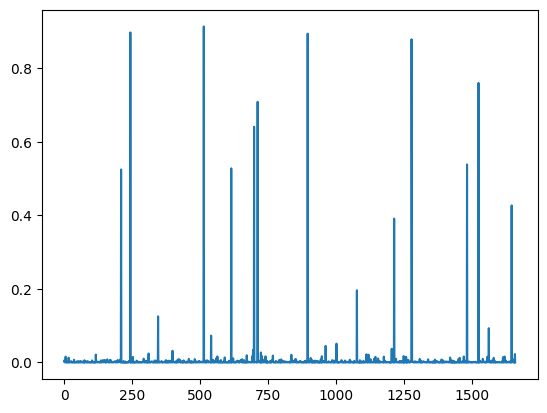

In [ ]:
evaluation["first_class_1"]==evaluation["nace_lvl_1"]

('G', 'M')